# Credit Risk Modeling in Python

https://www.datacamp.com/courses/credit-risk-modeling-in-python

## Block 4 - Model Evaluation and Implementation

After developing and testing two powerful machine learning models, we use key performance metrics to compare them. Using advanced model selection techniques specifically for financial modeling, we will select one model. With that model, we will: develop a business strategy, estimate portfolio value, and minimize expected loss.

In [18]:
# Mock Models for Comparison
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score
import xgboost as xgb

df = pd.read_csv("cr_loan_w2.csv")
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=610)

# 1 - Logistic Regression
model_lg = LogisticRegression(solver="liblinear").fit(X_train, y_train)
pred_lg = model_lg.predict(X_test) # Classification 
pred_prob_lg = model_lg.predict_proba(X_test)[:,1] # Probability of Default
print("Accuracy Logistic Regression: " + str(accuracy_score(y_test, pred_lg)))

# 2 - Gradient Boostes Trees
model_gb = xgb.XGBClassifier().fit(X_train, y_train)
pred_gb = model_gb.predict(X_test) # Classification
pred_prob_gb = model_gb.predict_proba(X_test)[:,1] # Probability of Default
print("Accuracy XGB: " + str(accuracy_score(y_test, pred_gb))) # much better! Accuracy = (TP + TN) / (TP + TN + FP + FN)

Accuracy Logistic Regression: 0.8255261371350985
Accuracy XGB: 0.9327053632043448


### Comparing model reports

One of the easiest first steps for comparing different models' ability to predict the probability of default is to look at their metrics from the **classification_report()**.

In [19]:
from sklearn.metrics import classification_report

target_names = ["Non-Default", "Default"]

# Report Logistic Regression
print(classification_report(y_test, pred_lg, target_names=target_names))

# Report XGB
print(classification_report(y_test, pred_gb, target_names=target_names))

              precision    recall  f1-score   support

 Non-Default       0.83      0.97      0.90      9232
     Default       0.74      0.30      0.43      2552

    accuracy                           0.83     11784
   macro avg       0.78      0.64      0.66     11784
weighted avg       0.81      0.83      0.80     11784

              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      9232
     Default       0.95      0.73      0.82      2552

    accuracy                           0.93     11784
   macro avg       0.94      0.86      0.89     11784
weighted avg       0.93      0.93      0.93     11784



### Comparing with ROCs (receiver operating characteristic)

A graph of **true positive rate** (= recall) versus **false positive rate** for different classification thresholds in binary classification.

- True Positive Rate (TPR) = TP / (TP + FN)
- False Positive Rate (FPR) = FP / (FP + TP)

Logistic Regression AUC score: 0.7900308335325404
XGB AUC score: 0.9456229405828439


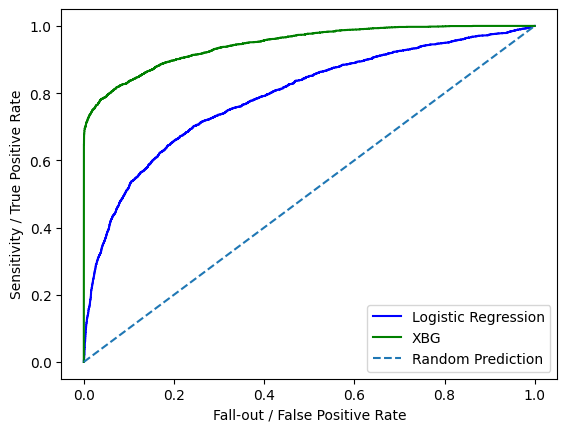

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC chart variables
fallout_lr, sensitivity_lr, thresholds_lr = roc_curve(y_test, pred_prob_lg)
fallout_gbt, sensitivity_gbt, thresholds_gbt = roc_curve(y_test, pred_prob_gb)

# Plot
plt.plot(fallout_lr, sensitivity_lr, c="blue", label="Logistic Regression")
plt.plot(fallout_gbt, sensitivity_gbt, c="green", label="XBG") # XGB has larger AUC!
plt.plot([0,1], [0,1], linestyle="--", label="Random Prediction")
plt.xlabel("Fall-out / False Positive Rate")
plt.ylabel("Sensitivity / True Positive Rate")
plt.legend()

# AUC Scores
print("Logistic Regression AUC score: " + str(roc_auc_score(y_test, pred_prob_lg)))
print("XGB AUC score: " + str(roc_auc_score(y_test, pred_prob_gb)))

### Calibration curves

You need to check the calibration of the two models **to see how stable the default prediction performance is across probabilities**. You can use a chart of each model's calibration to check this by calling the **calibration_curve()** function.